In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Customer Churn Prediction in Telecommunications


## Business Understanding


### Objective
The primary goal of this project is to predict customer churn in the telecommunications industry. Customer churn refers to the phenomenon where customers stop using a company's services and switch to competitors. Churn prediction is crucial for telecom companies as acquiring new customers is more costly than retaining existing ones. By identifying customers likely to churn, the company can take proactive measures to retain them through targeted offers and improved services.


### Business Problem
High customer churn rates negatively impact revenue and profitability. Predicting and addressing churn effectively can:
- Reduce customer acquisition costs.
- Improve customer satisfaction and loyalty.
- Enhance long-term profitability by retaining high-value customers.

### Key Questions
1. **Who is at risk of churning?**
2. **What factors contribute to customer churn?**
3. **How can the company use churn predictions to improve retention strategies?**

### Project Goals
- Develop machine learning models to accurately predict churn.
- Identify the most significant factors contributing to customer churn.
- Provide actionable insights to inform business strategies aimed at reducing churn.



## Data Understanding



In [2]:
# Load data
train_data = pd.read_csv('churn-bigml-80.csv')
test_data = pd.read_csv('churn-bigml-20.csv')

In [3]:
# Display basic information
print("Training Data Info:")
train_data.info()

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge  

In [4]:
print("\nTest Data Info:")
test_data.info()


Test Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      6

In [5]:
# Convert binary categorical variables to 0 and 1
train_data['International plan'] = train_data['International plan'].apply(lambda x: 1 if x == 'Yes' else 0)
train_data['Voice mail plan'] = train_data['Voice mail plan'].apply(lambda x: 1 if x == 'Yes' else 0)


In [6]:
print("Value counts for International plan:")
print(train_data['International plan'].value_counts())


Value counts for International plan:
International plan
0    2396
1     270
Name: count, dtype: int64


In [7]:
print("\nTest Data Info:")
train_data.info()


Test Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   int64  
 4   Voice mail plan         2666 non-null   int64  
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge     

In [8]:
# Summary statistics
print("\nTraining Data Statistics:")
print(train_data.describe())


Training Data Statistics:
       Account length    Area code  International plan  Voice mail plan  \
count     2666.000000  2666.000000         2666.000000      2666.000000   
mean       100.620405   437.438860            0.101275         0.274944   
std         39.563974    42.521018            0.301750         0.446570   
min          1.000000   408.000000            0.000000         0.000000   
25%         73.000000   408.000000            0.000000         0.000000   
50%        100.000000   415.000000            0.000000         0.000000   
75%        127.000000   510.000000            0.000000         1.000000   
max        243.000000   510.000000            1.000000         1.000000   

       Number vmail messages  Total day minutes  Total day calls  \
count            2666.000000         2666.00000      2666.000000   
mean                8.021755          179.48162       100.310203   
std                13.612277           54.21035        19.988162   
min                 0.000

In [9]:
# Define the target variable (y) and features (X)
X = train_data.drop(columns=['Churn'])  # Drop the target column
y = train_data['Churn']  # Target column


In [10]:
y.head()

0    False
1    False
2    False
3    False
4    False
Name: Churn, dtype: bool

In [11]:
X.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


**Checking for missing values**

In [12]:
# Check for missing values
print("\nMissing Values in Training Data:")
print(X.isnull().sum())


Missing Values in Training Data:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
dtype: int64


In [13]:
# Class distribution
print("\nChurn Distribution in Training Data:")
print(y.value_counts())


Churn Distribution in Training Data:
Churn
False    2278
True      388
Name: count, dtype: int64


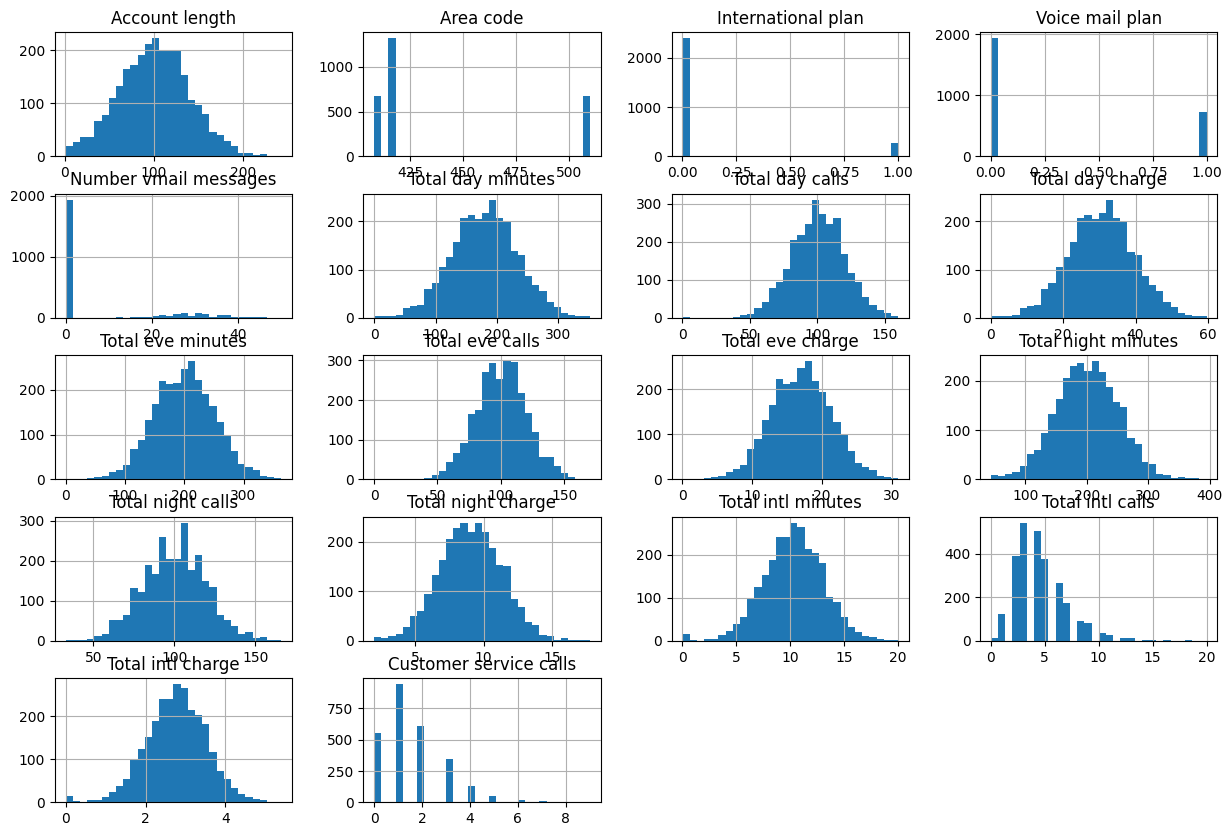

In [14]:
# Visualizations
# Histograms
X.hist(bins=30, figsize=(15, 10))
plt.show()

**Correlation between variables**

Columns in numerical_columns DataFrame:
Index(['Account length', 'Area code', 'International plan', 'Voice mail plan',
       'Number vmail messages', 'Total day minutes', 'Total day calls',
       'Total day charge', 'Total eve minutes', 'Total eve calls',
       'Total eve charge', 'Total night minutes', 'Total night calls',
       'Total night charge', 'Total intl minutes', 'Total intl calls',
       'Total intl charge', 'Customer service calls', 'Churn'],
      dtype='object')


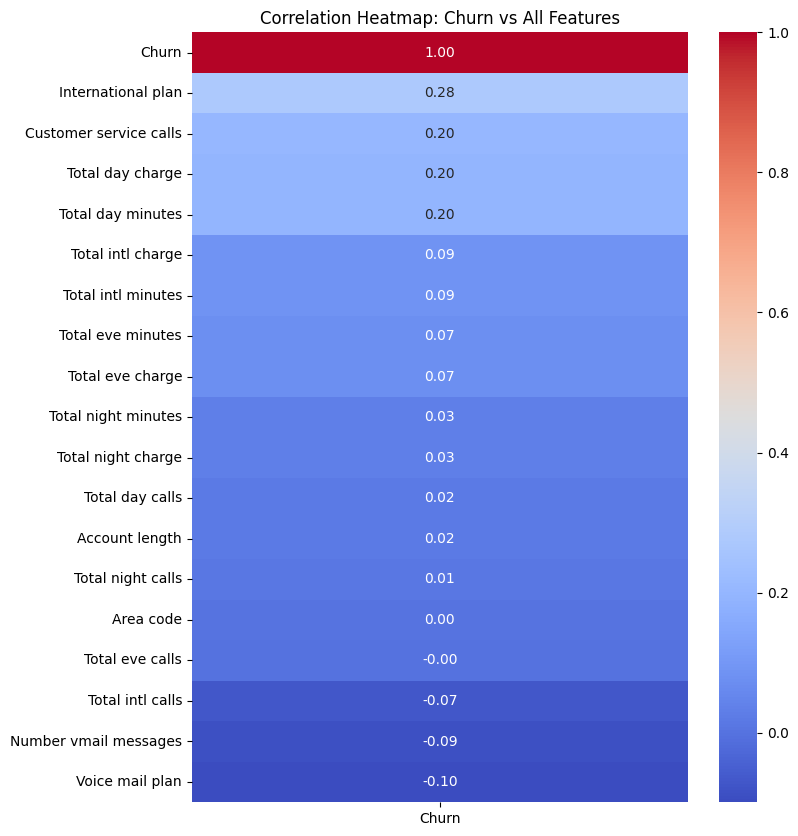

In [15]:
# Ensure 'Churn' is encoded as an integer
train_data['Churn'] = train_data['Churn'].astype(int)

# Select only numerical columns and ensure 'Churn' is included
numerical_columns = train_data.select_dtypes(include=['number'])

# Verify 'Churn' is in the numerical columns
print("Columns in numerical_columns DataFrame:")
print(numerical_columns.columns)

# Compute the correlation matrix for numerical columns
correlation_matrix = numerical_columns.corr()

# Plot the heatmap for correlation with Churn
plt.figure(figsize=(8, 10))
sns.heatmap(correlation_matrix[['Churn']].sort_values(by='Churn', ascending=False), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Churn vs All Features')
plt.show()


**Checking for outliers**

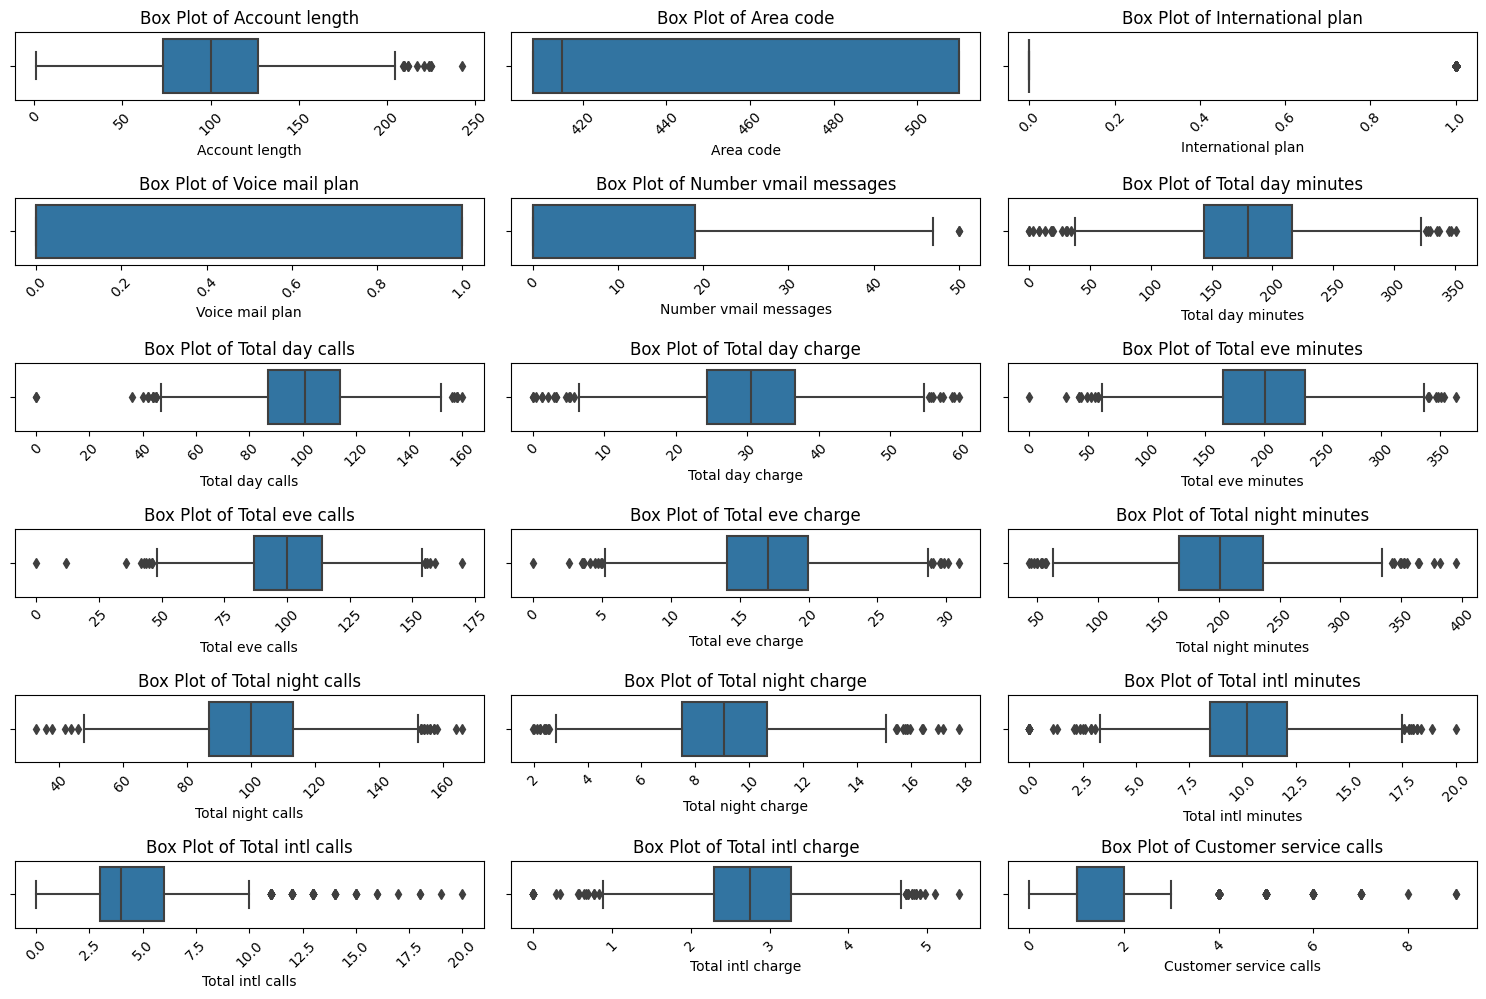

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get numerical columns from X
numerical_features = X.select_dtypes(include=['number']).columns

# Set up the number of rows and columns for the subplot grid
num_features = len(numerical_features)
num_cols = 3  # Number of box plots per row
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate rows based on number of columns

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Plot box plots for each numerical column
for i, column in enumerate(numerical_features):
    sns.boxplot(x=X[column], ax=axes[i])
    axes[i].set_title(f'Box Plot of {column}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-ticks for better readability

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Data preparation

**Treating outliers**

In [17]:
import pandas as pd
import numpy as np

def cap_outliers(df, column):
    """Cap outliers in a specified column using the IQR method."""
    Q1 = df[column].quantile(0.25)  # First quartile (25th percentile)
    Q3 = df[column].quantile(0.75)  # Third quartile (75th percentile)
    IQR = Q3 - Q1  # Interquartile range
    
    # Define lower and upper bounds for capping
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values beyond the lower and upper bounds
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

# Apply capping to all numerical columns
for col in X.select_dtypes(include=['number']).columns:
    cap_outliers(X, col)

# Display the updated DataFrame
print("Outliers capped successfully!")


Outliers capped successfully!


In [18]:
for col in X.select_dtypes(include=['number']).columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}: Min = {X[col].min()}, Max = {X[col].max()}, Bounds = ({lower_bound}, {upper_bound})")


Account length: Min = 1.0, Max = 208.0, Bounds = (-8.0, 208.0)
Area code: Min = 408.0, Max = 510.0, Bounds = (255.0, 663.0)
International plan: Min = 0.0, Max = 0.0, Bounds = (0.0, 0.0)
Voice mail plan: Min = 0.0, Max = 1.0, Bounds = (-1.5, 2.5)
Number vmail messages: Min = 0.0, Max = 47.5, Bounds = (-28.5, 47.5)
Total day minutes: Min = 34.650000000000006, Max = 324.65, Bounds = (34.650000000000006, 324.65)
Total day calls: Min = 46.5, Max = 154.5, Bounds = (46.5, 154.5)
Total day charge: Min = 5.899999999999995, Max = 55.18000000000001, Bounds = (5.899999999999995, 55.18000000000001)
Total eve minutes: Min = 60.60000000000004, Max = 339.79999999999995, Bounds = (60.60000000000004, 339.79999999999995)
Total eve calls: Min = 46.5, Max = 154.5, Bounds = (46.5, 154.5)
Total eve charge: Min = 5.155000000000001, Max = 28.875, Bounds = (5.155000000000001, 28.875)
Total night minutes: Min = 62.60000000000004, Max = 340.79999999999995, Bounds = (62.60000000000004, 340.79999999999995)
Total ni

**Checking if there are still outliers in the dataset**

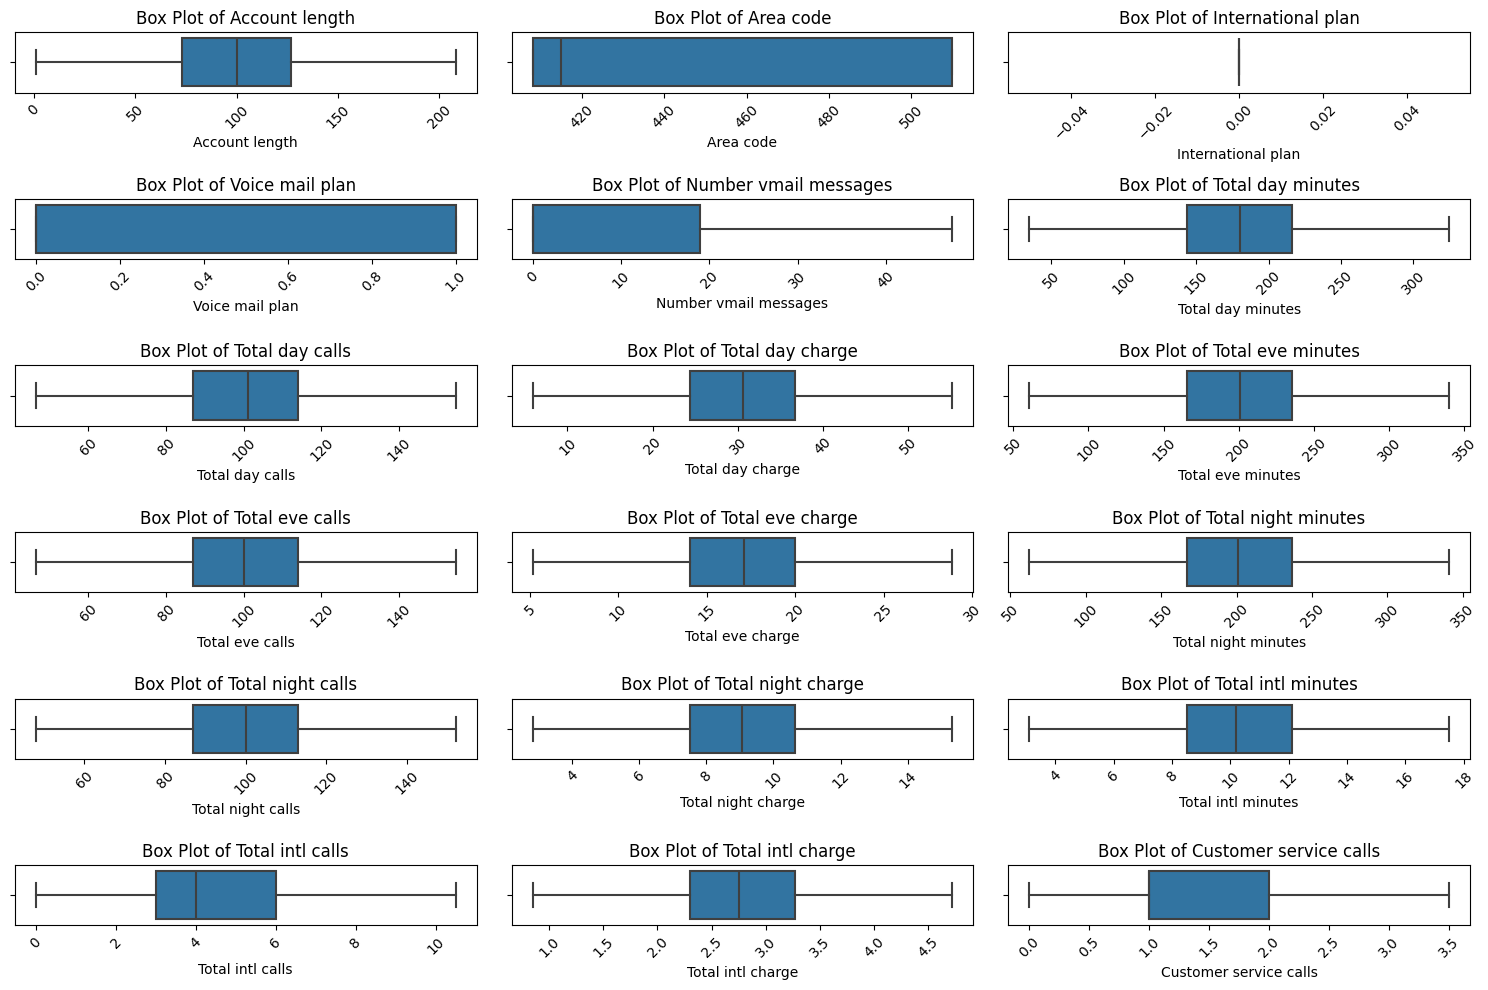

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get numerical columns from X
numerical_features = X.select_dtypes(include=['number']).columns

# Set up the number of rows and columns for the subplot grid
num_features = len(numerical_features)
num_cols = 3  # Number of box plots per row
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate rows based on number of columns

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Plot box plots for each numerical column
for i, column in enumerate(numerical_features):
    sns.boxplot(x=X[column], ax=axes[i])
    axes[i].set_title(f'Box Plot of {column}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-ticks for better readability

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**seperating features and target**

In [20]:
# Separate features (X) and target (y) in training and test data
X_train = train_data.drop(columns=['Churn'])
y_train = train_data['Churn']

X_test = test_data.drop(columns=['Churn'])
y_test = test_data['Churn']


**Class Distribution**

In [21]:
# Check class balance in the target variable
print("\nChurn Distribution in Training Data:")
print(y_train.value_counts())



Churn Distribution in Training Data:
Churn
0    2278
1     388
Name: count, dtype: int64


**Standardization using standardScaler**



In [22]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Encode binary categorical variables in both train and test datasets
X_train['International plan'] = X_train['International plan'].apply(lambda x: 1 if x == 'Yes' else 0)
X_train['Voice mail plan'] = X_train['Voice mail plan'].apply(lambda x: 1 if x == 'Yes' else 0)
X_test['International plan'] = X_test['International plan'].apply(lambda x: 1 if x == 'Yes' else 0)
X_test['Voice mail plan'] = X_test['Voice mail plan'].apply(lambda x: 1 if x == 'Yes' else 0)

# Step 2: Ensure feature columns in X_test match the order and names in X_train
X_test = X_test[X_train.columns]  # Align test dataset columns to match train dataset

# Step 3: Standardize numerical features
scaler = StandardScaler()
X_train_numeric = X_train.select_dtypes(include=['number'])
X_test_numeric = X_test.select_dtypes(include=['number'])

# Fit scaler on training data and transform both train and test data
X_train_standardized = scaler.fit_transform(X_train_numeric)
X_test_standardized = scaler.transform(X_test_numeric)

# Step 4: Convert standardized data back to DataFrame
X_train_standardized = pd.DataFrame(X_train_standardized, columns=X_train_numeric.columns)
X_test_standardized = pd.DataFrame(X_test_standardized, columns=X_test_numeric.columns)

# Verify standardized data
print("Train Data (Standardized):")
print(X_train_standardized.head())
print("\nTest Data (Standardized):")
print(X_test_standardized.head())


Train Data (Standardized):
   Account length  Area code  International plan  Voice mail plan  \
0        0.692163  -0.527811                 0.0              0.0   
1        0.161278  -0.527811                 0.0              0.0   
2        0.919686  -0.527811                 0.0              0.0   
3       -0.420168  -0.692467                 0.0              0.0   
4       -0.647691  -0.527811                 0.0              0.0   

   Number vmail messages  Total day minutes  Total day calls  \
0               1.247508           1.579670         0.484868   
1               1.320985          -0.329918         1.135375   
2              -0.589414           1.179302         0.685024   
3              -0.589414           2.212509        -1.466653   
4              -0.589414          -0.235822         0.634985   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0          1.579942          -0.058619        -0.050781         -0.058445   
1         -0.330194

**Verify if the data is standardized**

In [23]:
####verify
# Verify standardized data
print("\nStandardized Training Features (mean and std):")
print(X_train_standardized.describe().loc[['mean', 'std']])

print("\nStandardized Test Features:")
print(X_test_standardized.head())

# Check shapes
print("\nShapes of Standardized Data:")
print("X_train_standardized:", X_train_standardized.shape)
print("X_test_standardized:", X_test_standardized.shape)



Standardized Training Features (mean and std):
      Account length     Area code  International plan  Voice mail plan  \
mean   -1.292623e-16 -4.684092e-16                 0.0              0.0   
std     1.000188e+00  1.000188e+00                 0.0              0.0   

      Number vmail messages  Total day minutes  Total day calls  \
mean          -2.665202e-17       1.399231e-16     2.212117e-16   
std            1.000188e+00       1.000188e+00     1.000188e+00   

      Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
mean     -2.198791e-16      -1.119385e-16     3.104960e-16      2.811788e-16   
std       1.000188e+00       1.000188e+00     1.000188e+00      1.000188e+00   

      Total night minutes  Total night calls  Total night charge  \
mean         5.996704e-16      -2.198791e-17       -3.038330e-16   
std          1.000188e+00       1.000188e+00        1.000188e+00   

      Total intl minutes  Total intl calls  Total intl charge  \
mean       -2

**Feature Selection**

**1.Deleting highly correlated features**

In [24]:
import numpy as np
import pandas as pd

def delete_correlated_features(train_df, test_df, threshold=0.9):
    """
    Removes features with correlations higher than the threshold from both training and test datasets.
    Ensures alignment of features in both datasets.
    
    Parameters:
    - train_df: Training DataFrame
    - test_df: Test DataFrame
    - threshold: Correlation threshold for feature removal
    
    Returns:
    - train_df_reduced: Reduced training DataFrame
    - test_df_reduced: Reduced test DataFrame
    """
    # Select only numeric columns from training data
    numeric_train_df = train_df.select_dtypes(include=['number'])
    
    # Compute the correlation matrix
    correlation_matrix = numeric_train_df.corr()
    
    # Upper triangle of the correlation matrix
    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    
    # Find columns to drop based on the threshold
    to_drop = [column for column in upper_triangle.columns if any(abs(upper_triangle[column]) > threshold)]
    
    # Drop correlated features from both train and test DataFrames
    train_df_reduced = train_df.drop(columns=to_drop)
    test_df_reduced = test_df.drop(columns=to_drop)
    
    return train_df_reduced, test_df_reduced

# Example usage:
# Assuming X_train and X_test are your feature DataFrames
X_train_reduced, X_test_reduced = delete_correlated_features(X_train, X_test, threshold=0.9)

print(f"New shape of training data: {X_train_reduced.shape}")
print(f"New shape of test data: {X_test_reduced.shape}")
print(f"Remaining features: {list(X_train_reduced.columns)}")


New shape of training data: (2666, 15)
New shape of test data: (667, 15)
Remaining features: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls']


**2.Keeping K-Best features**

In [25]:
from sklearn.feature_selection import SelectKBest, chi2

# Apply SelectKBest
k = 10  # Select top 10 features
X_train_reduced_numeric = X_train_reduced.select_dtypes(include=['number'])  # Use numeric features for chi2
X_test_reduced_numeric = X_test_reduced.select_dtypes(include=['number'])

selector = SelectKBest(score_func=chi2, k=k)
X_train_selected = selector.fit_transform(X_train_reduced_numeric, y_train)

# Apply the same transformation to the test set
X_test_selected = selector.transform(X_test_reduced_numeric)

# Get the selected feature names
selected_features = X_train_reduced_numeric.columns[selector.get_support()]
print(f"Selected features: {list(selected_features)}")
print(f"X_train shape after SelectKBest: {X_train_selected.shape}")
print(f"X_test shape after SelectKBest: {X_test_selected.shape}")


Selected features: ['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls']
X_train shape after SelectKBest: (2666, 10)
X_test shape after SelectKBest: (667, 10)


# MODELING

**RandomForest**


Random Forest Metrics:
Accuracy: 0.9280
Precision: 0.7765
Recall: 0.6947
F1-Score: 0.7333
ROC-AUC: 0.8694

Confusion Matrix (Random Forest):
[[553  19]
 [ 29  66]]


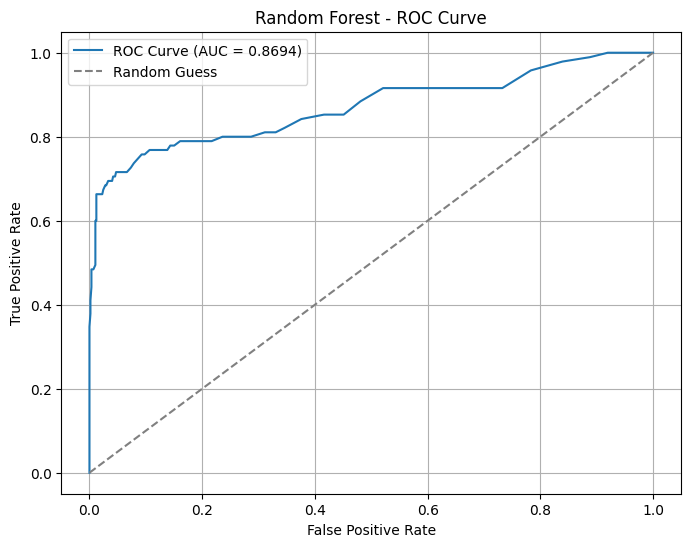

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Random Forest Model
random_forest = RandomForestClassifier(random_state=42)

pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', random_forest)
])

# Train the model on the selected features
pipeline_rf.fit(X_train_selected, y_train)

# Make predictions
y_pred_rf = pipeline_rf.predict(X_test_selected)
y_pred_proba_rf = pipeline_rf.predict_proba(X_test_selected)[:, 1]

# Calculate Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("\nRandom Forest Metrics:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix (Random Forest):")
print(conf_matrix_rf)

# ROC Curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"ROC Curve (AUC = {roc_auc_rf:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.title("Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


**GradientBoosting**


Gradient Boosting Metrics:
Accuracy: 0.9190
Precision: 0.7470
Recall: 0.6526
F1-Score: 0.6966
ROC-AUC: 0.8670

Confusion Matrix (Gradient Boosting):
[[551  21]
 [ 33  62]]


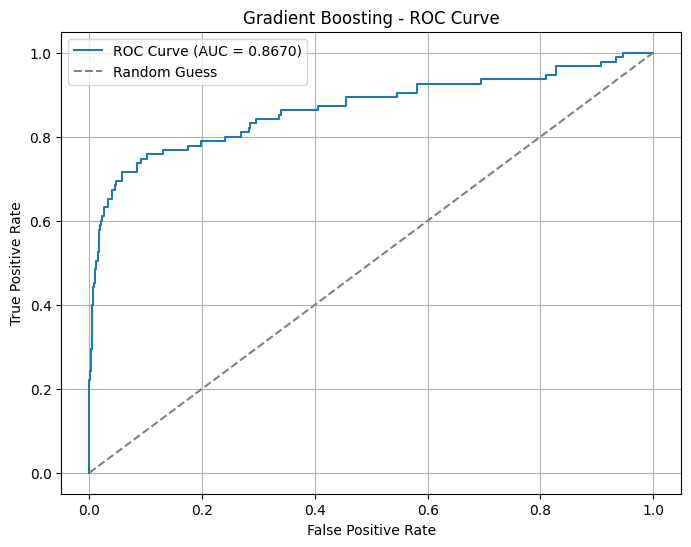

In [31]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Gradient Boosting Model
gb_classifier = GradientBoostingClassifier(random_state=42)

pipeline_gb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', gb_classifier)
])

# Train the model on selected features
pipeline_gb.fit(X_train_selected, y_train)

# Make predictions
y_pred_gb = pipeline_gb.predict(X_test_selected)
y_pred_proba_gb = pipeline_gb.predict_proba(X_test_selected)[:, 1]

# Calculate Metrics
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print("\nGradient Boosting Metrics:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-Score: {f1_gb:.4f}")
print(f"ROC-AUC: {roc_auc_gb:.4f}")

# Confusion Matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
print("\nConfusion Matrix (Gradient Boosting):")
print(conf_matrix_gb)

# ROC Curve
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_pred_proba_gb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, label=f"ROC Curve (AUC = {roc_auc_gb:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.title("Gradient Boosting - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


**XGBOOST**

C:\Users\dell\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:44:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Metrics:
Accuracy: 0.9355
Precision: 0.8023
Recall: 0.7263
F1-Score: 0.7624
ROC-AUC: 0.8855

Confusion Matrix (XGBoost):
[[555  17]
 [ 26  69]]


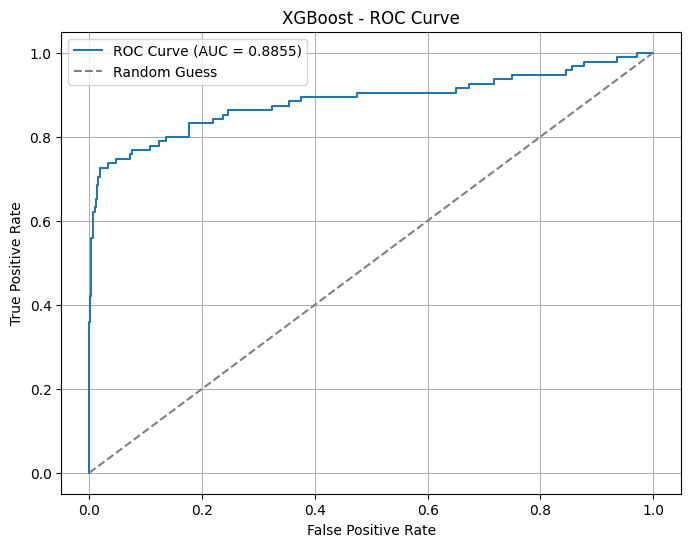

In [33]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# XGBoost Model
xgb_classifier = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

pipeline_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb_classifier)
])

# Train the model on selected features
pipeline_xgb.fit(X_train_selected, y_train)

# Make predictions
y_pred_xgb = pipeline_xgb.predict(X_test_selected)
y_pred_proba_xgb = pipeline_xgb.predict_proba(X_test_selected)[:, 1]

# Calculate Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("\nXGBoost Metrics:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")

# Confusion Matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix (XGBoost):")
print(conf_matrix_xgb)

# ROC Curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"ROC Curve (AUC = {roc_auc_xgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.title("XGBoost - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


**SVM**


SVM Metrics:
Accuracy: 0.8591
Precision: 0.5048
Recall: 0.5579
F1-Score: 0.5300
ROC-AUC: 0.7829

Confusion Matrix (SVM):
[[520  52]
 [ 42  53]]


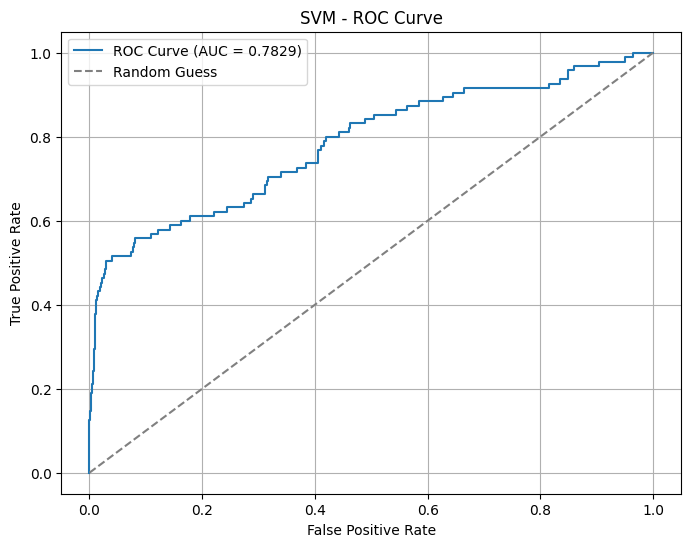

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# SVM Model
svm_classifier = SVC(random_state=42, probability=True)

pipeline_svm = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', svm_classifier)
])

# Train the model on selected features
pipeline_svm.fit(X_train_selected, y_train)

# Make predictions
y_pred_svm = pipeline_svm.predict(X_test_selected)
y_pred_proba_svm = pipeline_svm.predict_proba(X_test_selected)[:, 1]

# Calculate Metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)

print("\nSVM Metrics:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print(f"ROC-AUC: {roc_auc_svm:.4f}")

# Confusion Matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix (SVM):")
print(conf_matrix_svm)

# ROC Curve
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_proba_svm)
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"ROC Curve (AUC = {roc_auc_svm:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.title("SVM - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


**KNeighborsClassifier**

In [35]:
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

# k-Nearest Neighbors Model
knn_classifier = KNeighborsClassifier()

pipeline_knn = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', knn_classifier)
])

# Train the kNN model on selected features
pipeline_knn.fit(X_train_selected, y_train)

# Make predictions
y_pred_knn = pipeline_knn.predict(X_test_selected)
y_pred_proba_knn = pipeline_knn.predict_proba(X_test_selected)[:, 1]

# Calculate Metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

print("\nk-Nearest Neighbors Metrics:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print(f"ROC-AUC: {roc_auc_knn:.4f}")

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix (kNN):")
print(conf_matrix_knn)



k-Nearest Neighbors Metrics:
Accuracy: 0.6972
Precision: 0.2579
Recall: 0.6000
F1-Score: 0.3608
ROC-AUC: 0.7046

Confusion Matrix (kNN):
[[408 164]
 [ 38  57]]


**Logistic Regression**

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Train Logistic Regression
lr_classifier = LogisticRegression(random_state=42, max_iter=1000)
pipeline_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', lr_classifier)
])

pipeline_lr.fit(X_train_selected, y_train)
y_pred_lr = pipeline_lr.predict(X_test_selected)
y_pred_proba_lr = pipeline_lr.predict_proba(X_test_selected)[:, 1]

# Calculate Metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print("\nLogistic Regression Metrics:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"ROC-AUC: {roc_auc_lr:.4f}")



Logistic Regression Metrics:
Accuracy: 0.7166
Precision: 0.2974
Recall: 0.7263
F1-Score: 0.4220
ROC-AUC: 0.7868


# Model Performance Comparision


Model Comparison:
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression  0.716642   0.297414  0.726316  0.422018  0.786824
Random Forest        0.928036   0.776471  0.694737  0.733333  0.869424
Gradient Boosting    0.919040   0.746988  0.652632  0.696629  0.867022
XGBoost              0.935532   0.802326  0.726316  0.762431  0.885480
SVM                  0.859070   0.504762  0.557895  0.530000  0.782904
kNN                  0.697151   0.257919  0.600000  0.360759  0.704564


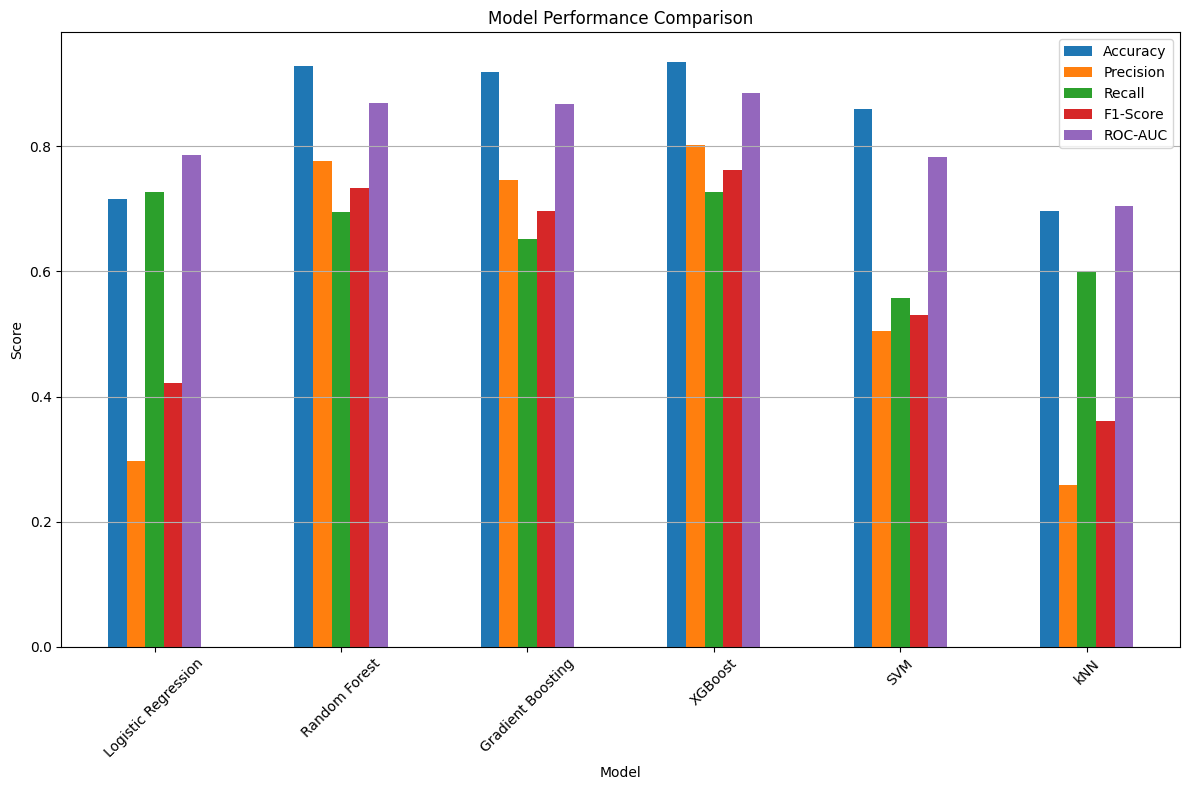

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Results for all models
results = {
    "Logistic Regression": {
        'Accuracy': accuracy_lr,
        'Precision': precision_lr,
        'Recall': recall_lr,
        'F1-Score': f1_lr,
        'ROC-AUC': roc_auc_lr
    },
    "Random Forest": {
        'Accuracy': accuracy_rf,
        'Precision': precision_rf,
        'Recall': recall_rf,
        'F1-Score': f1_rf,
        'ROC-AUC': roc_auc_rf
    },
    "Gradient Boosting": {
        'Accuracy': accuracy_gb,
        'Precision': precision_gb,
        'Recall': recall_gb,
        'F1-Score': f1_gb,
        'ROC-AUC': roc_auc_gb
    },
    "XGBoost": {
        'Accuracy': accuracy_xgb,
        'Precision': precision_xgb,
        'Recall': recall_xgb,
        'F1-Score': f1_xgb,
        'ROC-AUC': roc_auc_xgb
    },
    "SVM": {
        'Accuracy': accuracy_svm,
        'Precision': precision_svm,
        'Recall': recall_svm,
        'F1-Score': f1_svm,
        'ROC-AUC': roc_auc_svm
    },
    "kNN": {
        'Accuracy': accuracy_knn,
        'Precision': precision_knn,
        'Recall': recall_knn,
        'F1-Score': f1_knn,
        'ROC-AUC': roc_auc_knn
    }
}

# Convert to DataFrame and print results
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)

# Bar Plot for Comparison
results_df.plot(kind='bar', figsize=(12, 8))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# 1. Random Forest - Hyperparameter Tuning

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Define Random Forest and SMOTE pipeline
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define hyperparameters for Grid Search
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Grid Search for best parameters
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

# Fit Grid Search
rf_grid_search.fit(X_train_selected, y_train)

# Best Model
rf_best_model = rf_grid_search.best_estimator_

# Make predictions on the test set
y_pred_rf_tuned = rf_best_model.predict(X_test_selected)
y_pred_proba_rf_tuned = rf_best_model.predict_proba(X_test_selected)[:, 1]

# Calculate Metrics
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)
roc_auc_rf_tuned = roc_auc_score(y_test, y_pred_proba_rf_tuned)

print("\nTuned Random Forest Metrics:")
print(f"Accuracy: {accuracy_rf_tuned:.4f}")
print(f"Precision: {precision_rf_tuned:.4f}")
print(f"Recall: {recall_rf_tuned:.4f}")
print(f"F1-Score: {f1_rf_tuned:.4f}")
print(f"ROC-AUC: {roc_auc_rf_tuned:.4f}")

# Confusion Matrix
conf_matrix_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
print("\nConfusion Matrix (Tuned Random Forest):")
print(conf_matrix_rf_tuned)


Fitting 5 folds for each of 81 candidates, totalling 405 fits

Tuned Random Forest Metrics:
Accuracy: 0.9145
Precision: 0.7021
Recall: 0.6947
F1-Score: 0.6984
ROC-AUC: 0.8813

Confusion Matrix (Tuned Random Forest):
[[544  28]
 [ 29  66]]


# 2. Gradient Boosting - Hyperparameter Tuning


In [51]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

# Define the Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(random_state=42)

# Define hyperparameters for tuning
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Set up GridSearchCV
gb_grid_search = GridSearchCV(
    estimator=gb_classifier,
    param_grid=gb_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Perform grid search
gb_grid_search.fit(X_train_selected, y_train)

# Get the best model
gb_best_model = gb_grid_search.best_estimator_

# Make predictions on the test set
y_pred_gb_tuned = gb_best_model.predict(X_test_selected)
y_pred_proba_gb_tuned = gb_best_model.predict_proba(X_test_selected)[:, 1]

# Calculate Metrics
accuracy_gb_tuned = accuracy_score(y_test, y_pred_gb_tuned)
precision_gb_tuned = precision_score(y_test, y_pred_gb_tuned)
recall_gb_tuned = recall_score(y_test, y_pred_gb_tuned)
f1_gb_tuned = f1_score(y_test, y_pred_gb_tuned)
roc_auc_gb_tuned = roc_auc_score(y_test, y_pred_proba_gb_tuned)

print("\nTuned Gradient Boosting Metrics:")
print(f"Accuracy: {accuracy_gb_tuned:.4f}")
print(f"Precision: {precision_gb_tuned:.4f}")
print(f"Recall: {recall_gb_tuned:.4f}")
print(f"F1-Score: {f1_gb_tuned:.4f}")
print(f"ROC-AUC: {roc_auc_gb_tuned:.4f}")

# Confusion Matrix
conf_matrix_gb_tuned = confusion_matrix(y_test, y_pred_gb_tuned)
print("\nConfusion Matrix (Tuned Gradient Boosting):")
print(conf_matrix_gb_tuned)


Fitting 5 folds for each of 27 candidates, totalling 135 fits

Tuned Gradient Boosting Metrics:
Accuracy: 0.9430
Precision: 0.9014
Recall: 0.6737
F1-Score: 0.7711
ROC-AUC: 0.8968

Confusion Matrix (Tuned Gradient Boosting):
[[565   7]
 [ 31  64]]


# 3. XGBoost - Hyperparameter Tuning


In [52]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

# Define the XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define hyperparameters for tuning
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Set up GridSearchCV
xgb_grid_search = GridSearchCV(
    estimator=xgb_classifier,
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Perform grid search
xgb_grid_search.fit(X_train_selected, y_train)

# Get the best model
xgb_best_model = xgb_grid_search.best_estimator_

# Make predictions on the test set
y_pred_xgb_tuned = xgb_best_model.predict(X_test_selected)
y_pred_proba_xgb_tuned = xgb_best_model.predict_proba(X_test_selected)[:, 1]

# Calculate Metrics
accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)
roc_auc_xgb_tuned = roc_auc_score(y_test, y_pred_proba_xgb_tuned)

print("\nTuned XGBoost Metrics:")
print(f"Accuracy: {accuracy_xgb_tuned:.4f}")
print(f"Precision: {precision_xgb_tuned:.4f}")
print(f"Recall: {recall_xgb_tuned:.4f}")
print(f"F1-Score: {f1_xgb_tuned:.4f}")
print(f"ROC-AUC: {roc_auc_xgb_tuned:.4f}")

# Confusion Matrix
conf_matrix_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
print("\nConfusion Matrix (Tuned XGBoost):")
print(conf_matrix_xgb_tuned)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


C:\Users\dell\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:24:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Tuned XGBoost Metrics:
Accuracy: 0.9385
Precision: 0.9500
Recall: 0.6000
F1-Score: 0.7355
ROC-AUC: 0.9001

Confusion Matrix (Tuned XGBoost):
[[569   3]
 [ 38  57]]


**Finalizing XGBoost**

C:\Users\dell\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:24:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Final XGBoost Metrics:
Accuracy: 0.9355
Precision: 0.8714
Recall: 0.6421
F1-Score: 0.7394
ROC-AUC: 0.8906

Confusion Matrix (Final XGBoost):
[[563   9]
 [ 34  61]]


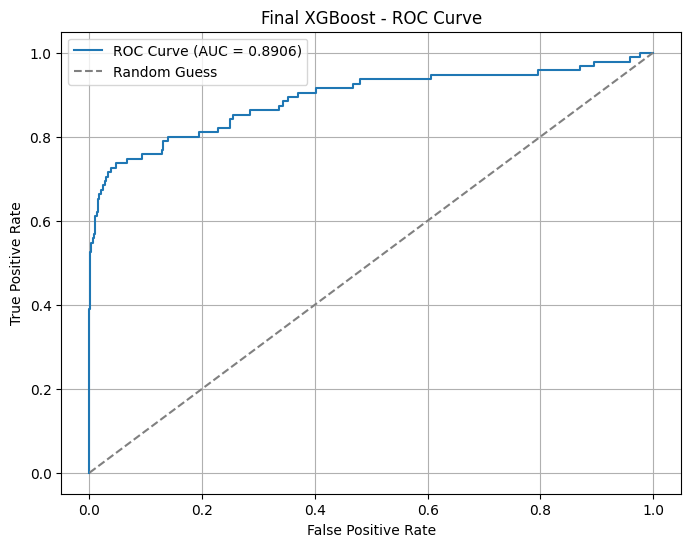

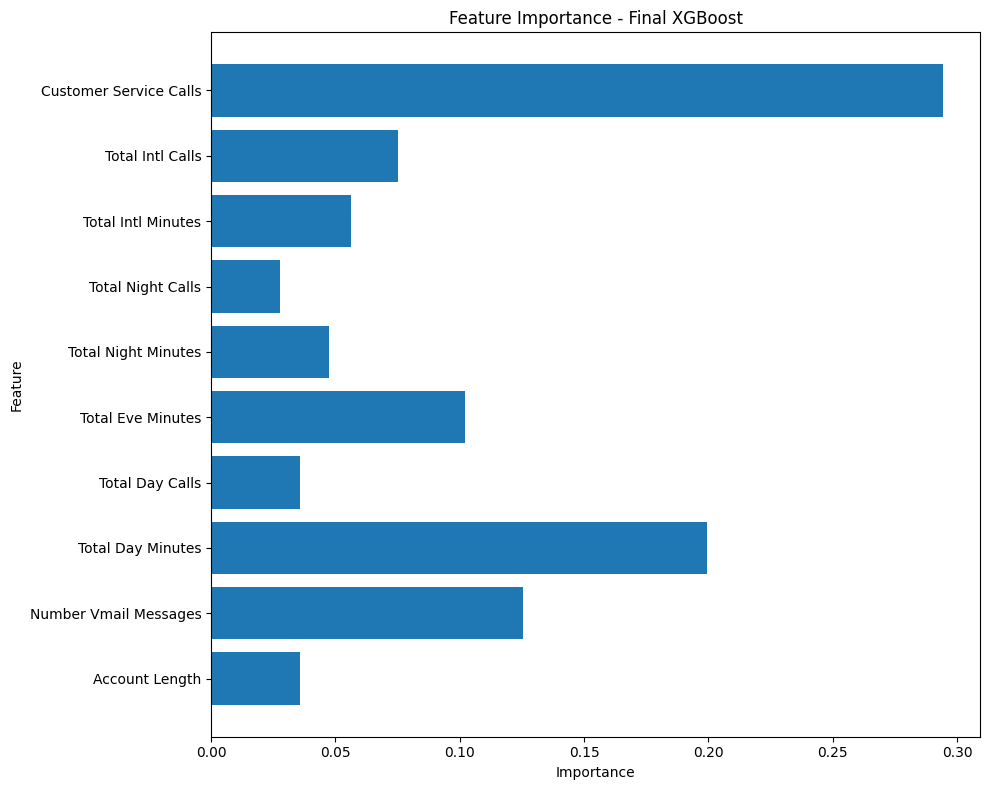

In [53]:
# Finalizing XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define feature names
feature_names = ['Account Length', 'Number Vmail Messages', 'Total Day Minutes', 'Total Day Calls', 'Total Eve Minutes',
                 'Total Night Minutes', 'Total Night Calls', 'Total Intl Minutes', 'Total Intl Calls', 'Customer Service Calls']

# Using the best parameters from the tuning phase
xgb_best_params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}  # Example parameters

xgb_final_model = XGBClassifier(
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss', 
    **xgb_best_params
)

# Train the final model on the entire training set
xgb_final_model.fit(X_train_selected, y_train)

# Make predictions on the test set
y_test_pred = xgb_final_model.predict(X_test_selected)
y_test_pred_proba = xgb_final_model.predict_proba(X_test_selected)[:, 1]

# Evaluate the final model
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("\nFinal XGBoost Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Final XGBoost):")
print(conf_matrix)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.title("Final XGBoost - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# Feature Importance
plt.figure(figsize=(10, 8))
plt.barh(feature_names, xgb_final_model.feature_importances_)
plt.title("Feature Importance - Final XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# SHAP Analysis

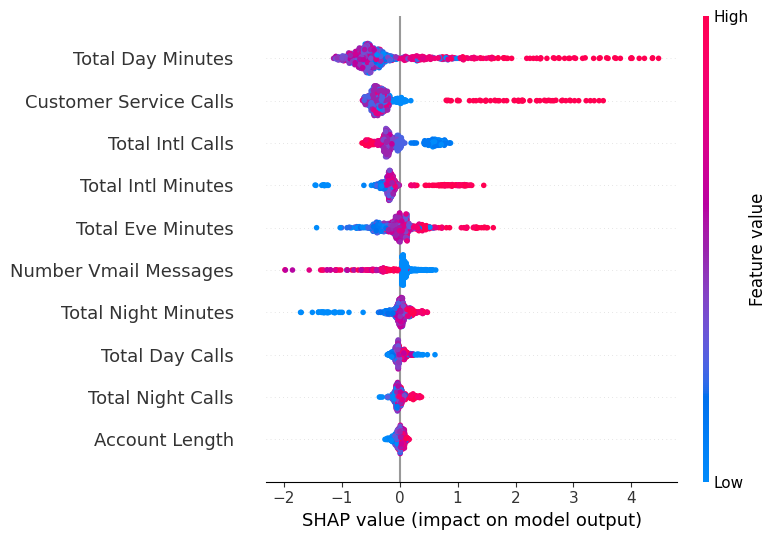

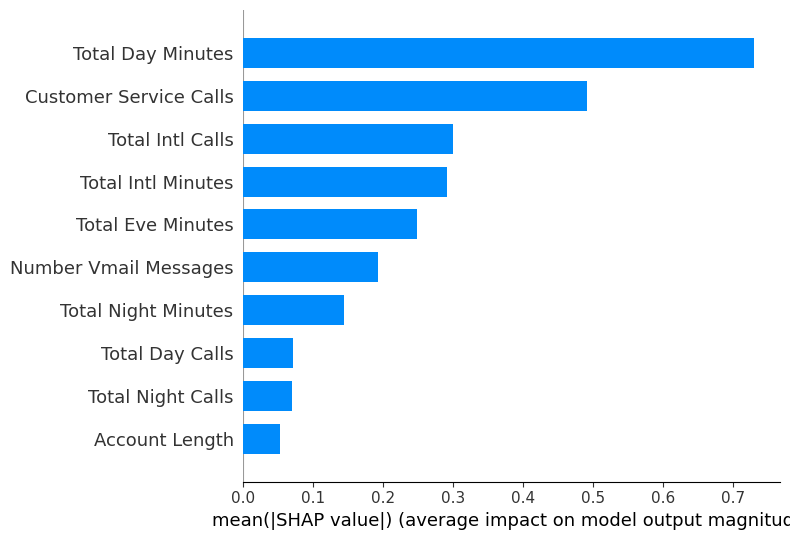

In [54]:
import shap
import numpy as np
import pandas as pd

# Convert X_test_selected to DataFrame for SHAP visualization
X_test_selected_df = pd.DataFrame(X_test_selected, columns=feature_names)

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(xgb_final_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_selected_df)

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_selected_df, feature_names=feature_names)

# SHAP Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_selected_df, feature_names=feature_names, plot_type="bar")




# Deployment:

In [55]:
import joblib

# Save the model
joblib.dump(xgb_final_model, 'xgboost_model.pkl')


['xgboost_model.pkl']

In [ ]:
#pip install flask fastapi uvicorn joblib pandas numpy
